In [ ]:
# 1. Imports.
# Following Raschka's code. Additionally, also import seaborn for readability of EDAs.

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Splitting data into train and test sets
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

#Standardize features and create modeling pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Model evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# 2. Load dataset.
df = pd.read_csv("housing2(2).csv")

df.head()

,ATT1,ATT2,ATT3,ATT4,ATT5,ATT6,ATT7,ATT8,ATT9,ATT10,...,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.038327,0.592379,0.655174,0.119839,0.652477,0.984323,0.206738,0.374650,0.463350,0.333610,...,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.225022,0.983103,0.803619,0.836315,0.163104,0.637497,0.008760,0.631190,0.207978,0.880357,...,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.423233,0.375808,0.271293,0.729824,0.886744,0.043703,0.457700,0.862450,0.901924,0.062488,...,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.743370,0.929103,0.589894,0.644012,0.110490,0.774604,0.306483,0.880599,0.630401,0.928894,...,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.378623,0.786609,0.712752,0.110274,0.762133,0.030069,0.316631,0.667073,0.426443,0.400557,...,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# 3.Inspect dataset

# Print dataset's dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Inspect variables
df.info()
df.columns

# From the inspection we confirm all columns are numeric, so no need for categorical encoding before regression

Number of rows: 506
Number of columns: 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 27 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ATT1     506 non-null    float64
 1   ATT2     506 non-null    float64
 2   ATT3     506 non-null    float64
 3   ATT4     506 non-null    float64
 4   ATT5     506 non-null    float64
 5   ATT6     506 non-null    float64
 6   ATT7     506 non-null    float64
 7   ATT8     506 non-null    float64
 8   ATT9     506 non-null    float64
 9   ATT10    506 non-null    float64
 10  ATT11    506 non-null    float64
 11  ATT12    506 non-null    float64
 12  ATT13    506 non-null    float64
 13  CRIM     506 non-null    float64
 14  ZN       506 non-null    float64
 15  INDUS    506 non-null    float64
 16  CHAS     506 non-null    int64  
 17  NOX      506 non-null    float64
 18  RM       506 non-null    float64
 19  AGE      506 non-null    float64
 20  DIS      506

Index(['ATT1', 'ATT2', 'ATT3', 'ATT4', 'ATT5', 'ATT6', 'ATT7', 'ATT8', 'ATT9',
       'ATT10', 'ATT11', 'ATT12', 'ATT13', 'CRIM', 'ZN', 'INDUS', 'CHAS',
       'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT',
       'MEDV'],
      dtype='object')

In [ ]:
# 4. Check for missing values
print("Total missing values:", df.isnull().sum().sum())

# There are no missing values, so we do not need to use dropna() or further process the data

Total missing values: 0


In [ ]:
# 5. Describe statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ATT1,506.0,0.518457,0.283847,0.000727,0.272918,0.521326,0.770235,0.995798
ATT2,506.0,0.500422,0.298752,0.000321,0.235879,0.485701,0.774921,0.999265
ATT3,506.0,0.507451,0.289607,0.000013,0.244897,0.526014,0.750546,0.998746
ATT4,506.0,0.498543,0.294229,0.001541,0.229861,0.506543,0.757517,0.995561
ATT5,506.0,0.525487,0.283387,0.003970,0.283208,0.514982,0.772218,0.998635
ATT6,506.0,0.508831,0.282400,0.000679,0.276366,0.509443,0.730899,0.998194
ATT7,506.0,0.501997,0.287986,0.003653,0.271701,0.499804,0.756420,0.999140
ATT8,506.0,0.509998,0.290160,0.000525,0.257320,0.508326,0.768465,0.997083
ATT9,506.0,0.480159,0.301086,0.001093,0.208171,0.465558,0.739580,0.996714
ATT10,506.0,0.501922,0.294051,0.000263,0.248119,0.487128,0.771559,0.999321


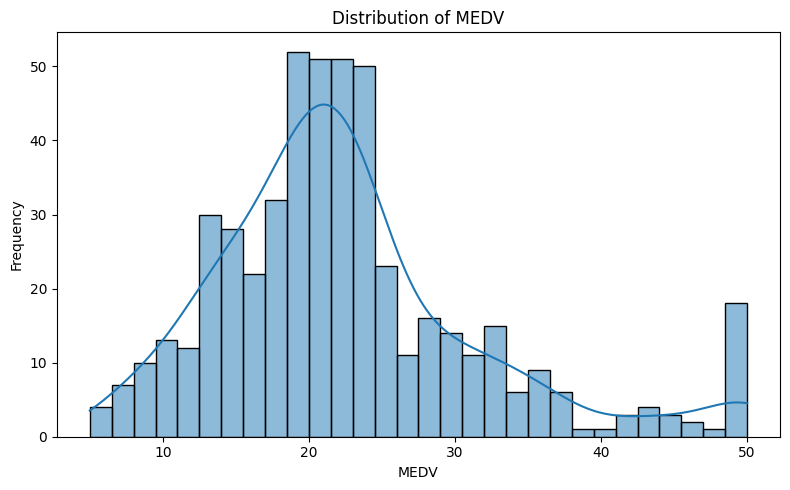

In [ ]:
# 6. MEDV (Target variable) distribution
# Get an idea of the distribution of the target variable

# Plot ditribution
plt.figure(figsize=(8, 5))

# Create a histogram with a density curve
sns.histplot(df["MEDV"], bins=30, kde=True)

# Label axes and title
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.title("Distribution of MEDV")

# Adjust spacing and display
plt.tight_layout()
plt.show()

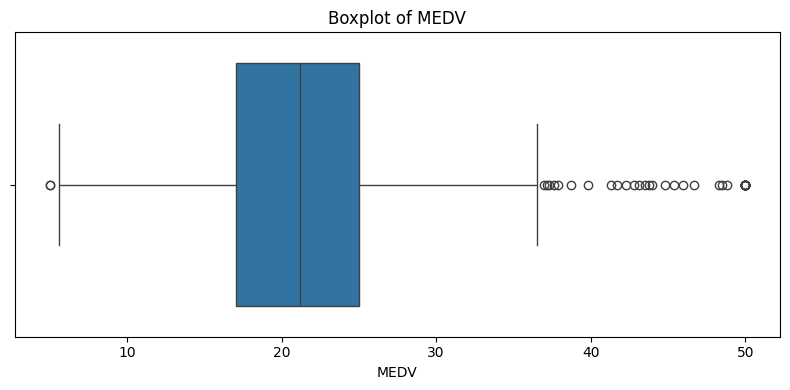

In [ ]:
# 7. MEDV Bloxplot.
# See if there are extreme values

# Plot distribution
plt.figure(figsize=(8, 4))

# Create Bloxplot
sns.boxplot(x=df["MEDV"])

# Label axis and title
plt.xlabel("MEDV")
plt.title("Boxplot of MEDV")

# Adjust spacing and display
plt.tight_layout()
plt.show()

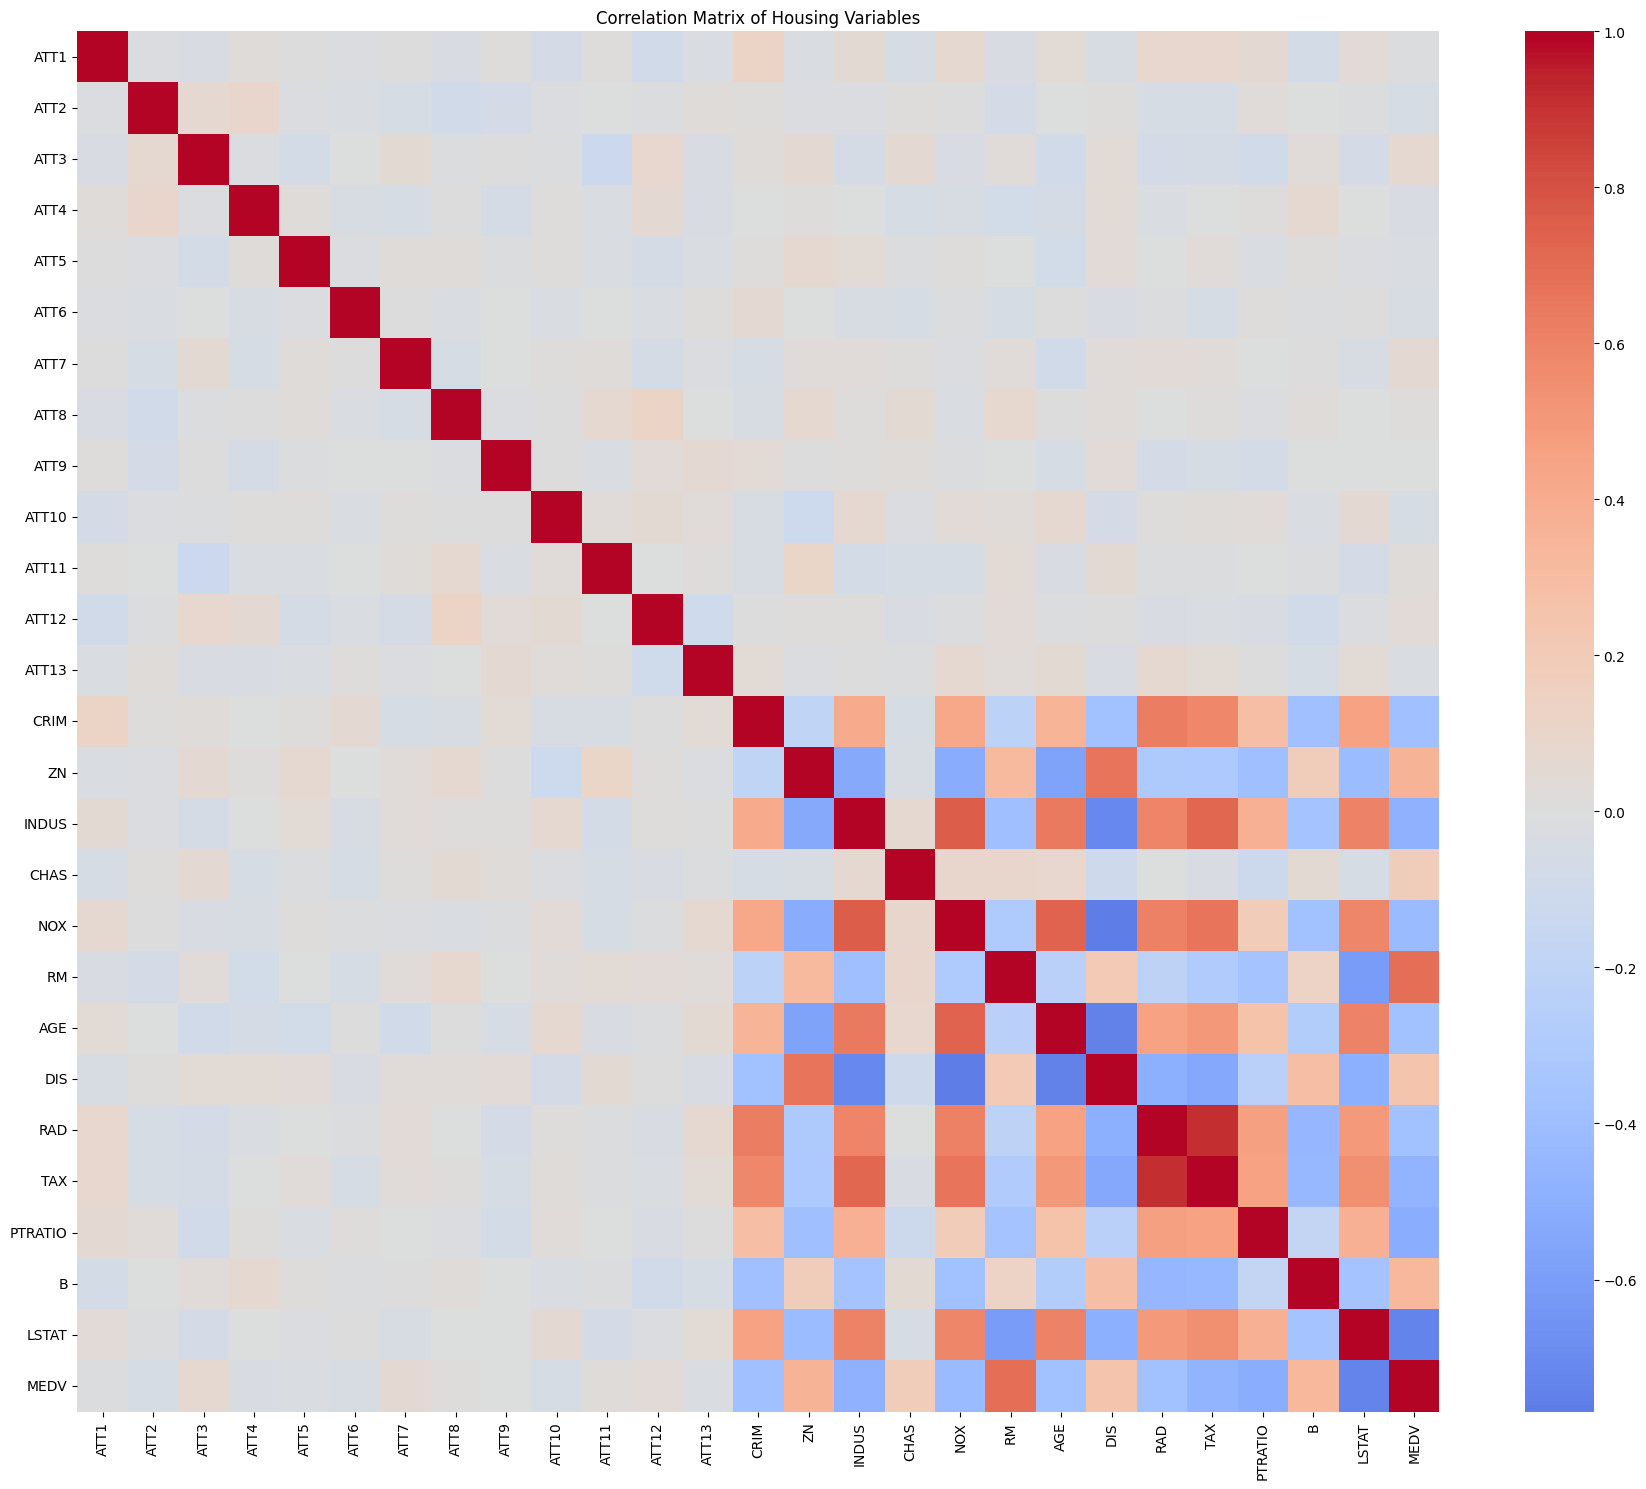

In [ ]:
# 8. Correlation matrix of all variables
# To see linear relationships between variables
# Note: Raschka put correlation coefficients in the heatmap, he only has 5 variables
# Because we have 27 variables, we don't put the coefficients or it will be unreadable

# Get correlation between variables
corr_matrix = df.corr()

# Plot
plt.figure(figsize=(18, 15))

# Create heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

# Give heatmap title
plt.title("Correlation Matrix of Housing Variables")

# Adjust spacing and display
plt.tight_layout()
plt.show()

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
ATT3       0.072681
ATT7       0.053808
ATT12      0.037420
ATT11      0.019218
ATT8       0.014681
ATT9      -0.008142
ATT1      -0.013067
ATT5      -0.025022
ATT13     -0.027971
ATT4      -0.029786
ATT6      -0.040822
ATT2      -0.049872
ATT10     -0.054528
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


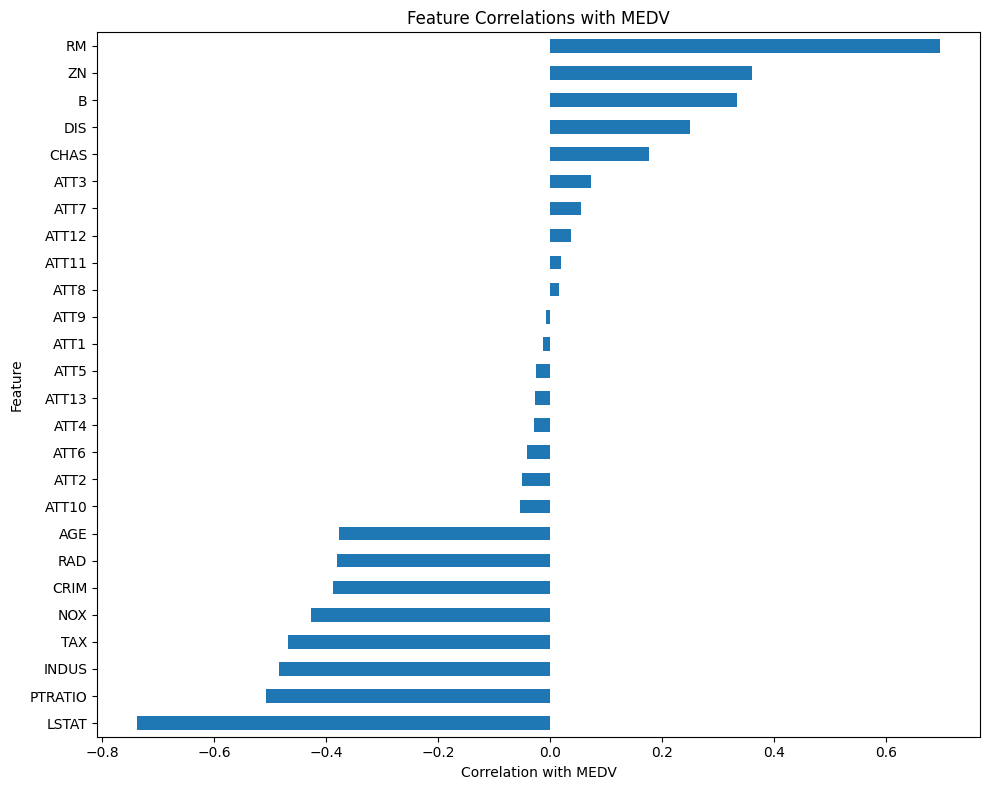

In [ ]:
# 9. Correlation specifically with MEDV

# Sort the correlations with the target variable MEDV
medv_corr = corr_matrix["MEDV"].sort_values(ascending=False)

#Display correlations
print(medv_corr)

# Plot the correlations
plt.figure(figsize=(10, 8))
medv_corr.drop("MEDV").sort_values().plot(kind="barh")

# Label axes and title
plt.xlabel("Correlation with MEDV")
plt.ylabel("Feature")
plt.title("Feature Correlations with MEDV")

#Adjust spacing and display
plt.tight_layout()
plt.show()

Selected features: ['MEDV', 'LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX']


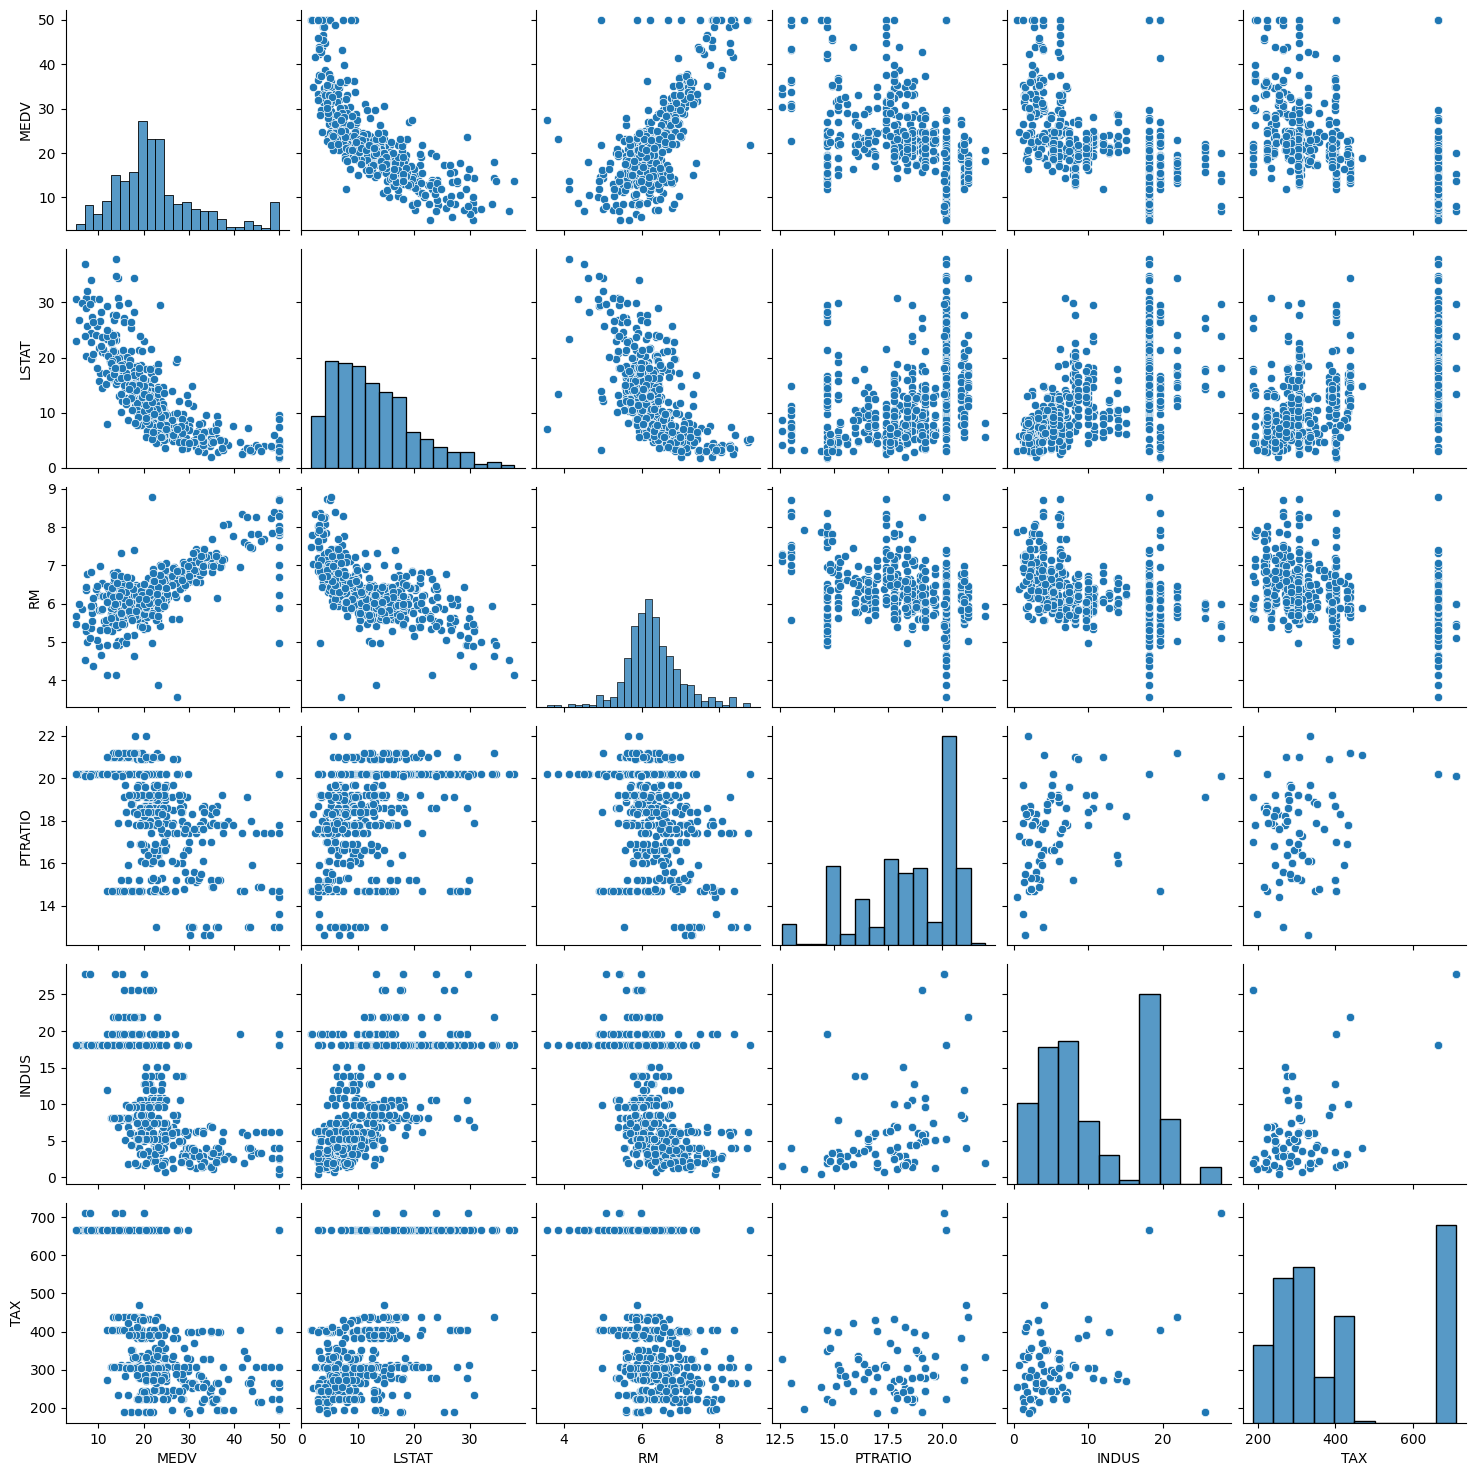

In [ ]:
# 10. Scatterplot matrix (selected)
# Raschka plotted all variables, but we have 27 of them, so we select the top 5 most correlated with MEDV

# Select the five features with the strongest absolute correlation with MEDV
top_features = (
    corr_matrix["MEDV"]
    .drop("MEDV")
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Add MEDV to the selected features
selected_features = ["MEDV"] + list(top_features)

# Display the features
print("Selected features:", selected_features)

# Create scatterplot matrix for MEDV and the five most correlated features
sns.pairplot(df[selected_features])

# Display
plt.show()


In [ ]:
# 11. Train/test split

target = "MEDV"

# Create feature and label
X = df.drop(columns=[target])
y = df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 26)
X_test shape: (102, 26)
y_train shape: (404,)
y_test shape: (102,)


In [ ]:
# 12. Implement linear regression

# Create linear regression model
linear_model = LinearRegression()

# Fit the model with training data
linear_model.fit(X_train, y_train)

# Display intercept
print("Intercept:", linear_model.intercept_)

# Table showing coefficient of each feature
linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

display(linear_coefficients)

# Make predictions using training and test data
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

Intercept: 29.01184117293089


,Feature,Coefficient
0,ATT1,2.895569
1,ATT2,-0.240287
2,ATT3,0.559300
3,ATT4,-0.105367
4,ATT5,-0.767932
5,ATT6,-0.619537
6,ATT7,0.666792
7,ATT8,-0.279369
8,ATT9,-0.141198
9,ATT10,-1.017553


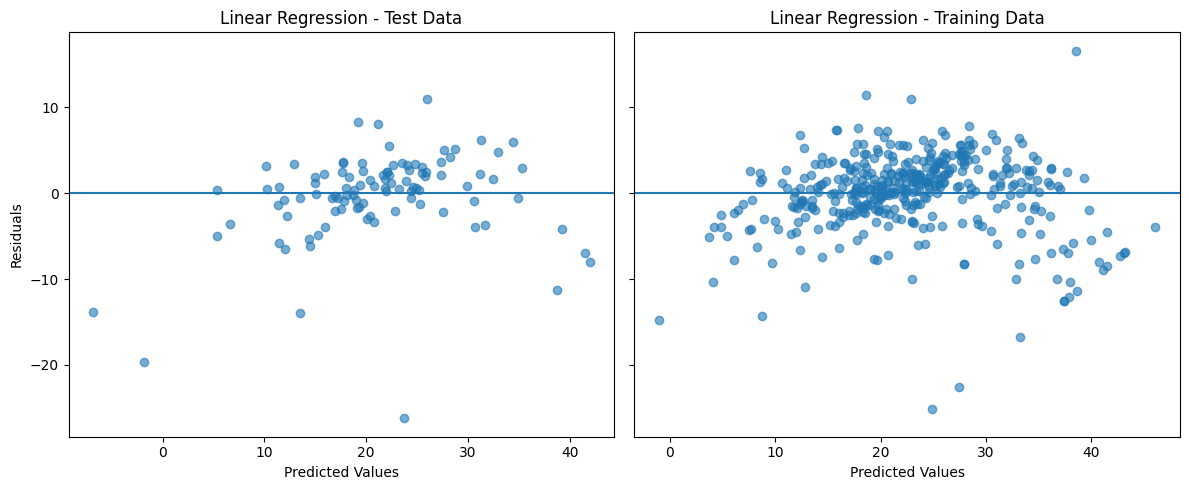

In [ ]:
# 13. Linear Regression redisual plots

# Create residual plots for training and test data
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True
)

# Plot residuals for test data
ax1.scatter(
    y_test_pred_linear,
    y_test_pred_linear - y_test,
    alpha=0.6
)

ax1.axhline(y=0)
ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("Residuals")
ax1.set_title("Linear Regression - Test Data")

# Plot residuals for training data
ax2.scatter(
    y_train_pred_linear,
    y_train_pred_linear - y_train,
    alpha=0.6
)

ax2.axhline(y=0)
ax2.set_xlabel("Predicted Values")
ax2.set_title("Linear Regression - Training Data")

# Adjust spacing and display
plt.tight_layout()
plt.show()

In [ ]:
# 14. MSE for linear regression

# Calculate MSE for training and test data
linear_mse_train = mean_squared_error(
    y_train,
    y_train_pred_linear
)

linear_mse_test = mean_squared_error(
    y_test,
    y_test_pred_linear
)

print("Linear Regression MSE - Training:", linear_mse_train)
print("Linear Regression MSE - Test:", linear_mse_test)

Linear Regression MSE - Training: 20.612846807058926
Linear Regression MSE - Test: 26.63023048426115


In [ ]:
# 15. Calculate R^2 for linear regression

linear_r2_train = r2_score(
    y_train,
    y_train_pred_linear
)

linear_r2_test = r2_score(
    y_test,
    y_test_pred_linear
)

print("Linear Regression R² - Training:", linear_r2_train)
print("Linear Regression R² - Test:", linear_r2_test)

Linear Regression R² - Training: 0.762725461446246
Linear Regression R² - Test: 0.6368627208821083


In [ ]:
# 16. Summary table for linear regression

linear_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Train MSE": [linear_mse_train],
    "Test MSE": [linear_mse_test],
    "Train R²": [linear_r2_train],
    "Test R²": [linear_r2_test]
})

linear_results

,Model,Train MSE,Test MSE,Train R²,Test R²
0,Linear Regression,20.612847,26.63023,0.762725,0.636863


In [ ]:
# 17. Ridge setup

# Cross-validation for selecting regularization strength
from sklearn.model_selection import cross_val_score

# Alpha values to test
ridge_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

In [ ]:
# 18. Fit ridge with different alphas

# Store the cross-validation results for each alpha
ridge_cv_results = []

# Test each alpha value
for alpha in ridge_alphas:

    # Create a pipeline that standardizes the features and fits Ridge regression
    ridge_model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    # Calculate 5-fold cross-validation MSE using only the training data
    cv_scores = cross_val_score(
        ridge_model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    # Convert negative MSE scores back to positive MSE
    mean_cv_mse = -cv_scores.mean()

    # Store result
    ridge_cv_results.append({
        "Alpha": alpha,
        "CV MSE": mean_cv_mse
    })

# Display results
ridge_cv_table = pd.DataFrame(ridge_cv_results)
display(ridge_cv_table)

,Alpha,CV MSE
0,0.0001,25.240082
1,0.0010,25.240064
2,0.0100,25.239886
3,0.1000,25.238120
4,1.0000,25.222208
5,10.0000,25.166188
6,100.0000,26.623877
7,1000.0000,44.770192


In [ ]:
# 19. Find best alpha for ridge

# Select the alpha with the lowest cross-validation MSE
best_ridge_alpha = ridge_cv_table.loc[
    ridge_cv_table["CV MSE"].idxmin(),
    "Alpha"
]

print("Best Ridge alpha:", best_ridge_alpha)

Best Ridge alpha: 10.0


In [ ]:
# 20. Fit the final ridge model
# Use alpha = 10

# Create the final Ridge model
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=best_ridge_alpha)
)

# Fit the model with training data
ridge_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(10.0)))])

In [ ]:
# 21. Intercept and coefficients for ridge

# Access the fitted Ridge regression model
ridge_regressor = ridge_model.named_steps["ridge"]

# Display intercept
print("Intercept:", ridge_regressor.intercept_)

# Create a table showing coefficient for each feature
ridge_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_regressor.coef_
})

display(ridge_coefficients)

Intercept: 22.796534653465343


,Feature,Coefficient
0,ATT1,0.787974
1,ATT2,-0.094102
2,ATT3,0.148851
3,ATT4,-0.037923
4,ATT5,-0.230781
5,ATT6,-0.155378
6,ATT7,0.199636
7,ATT8,-0.084975
8,ATT9,-0.051313
9,ATT10,-0.290047


In [ ]:
# 22. Make predictions
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

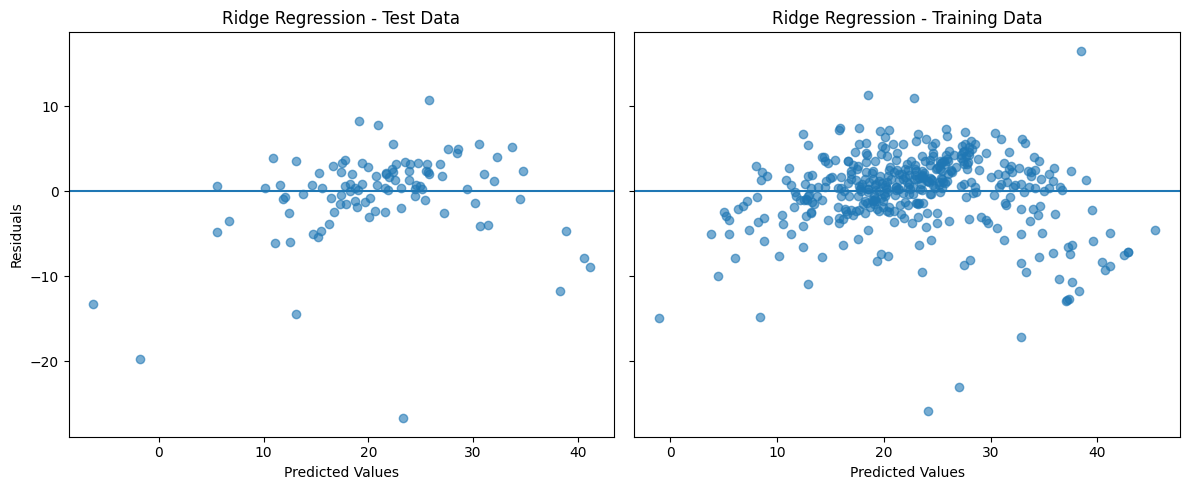

In [ ]:
# 23. Residual plots

# Create residual plots for the training and test data
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True
)

# Plot residuals for the test data
ax1.scatter(
    y_test_pred_ridge,
    y_test_pred_ridge - y_test,
    alpha=0.6
)

ax1.axhline(y=0)
ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("Residuals")
ax1.set_title("Ridge Regression - Test Data")

# Plot residuals for the training data
ax2.scatter(
    y_train_pred_ridge,
    y_train_pred_ridge - y_train,
    alpha=0.6
)

ax2.axhline(y=0)
ax2.set_xlabel("Predicted Values")
ax2.set_title("Ridge Regression - Training Data")

# Adjust spacing and display
plt.tight_layout()
plt.show()

In [ ]:
# 24. MSE for ridge

# Calculate MSE for training and test data
ridge_mse_train = mean_squared_error(
    y_train,
    y_train_pred_ridge
)

ridge_mse_test = mean_squared_error(
    y_test,
    y_test_pred_ridge
)

print("Ridge MSE - Training:", ridge_mse_train)
print("Ridge MSE - Test:", ridge_mse_test)

Ridge MSE - Training: 20.703816514781224
Ridge MSE - Test: 26.747206686923647


In [ ]:
# 25. R^2 for ridge

# Calculate R^ for the training and test data
ridge_r2_train = r2_score(
    y_train,
    y_train_pred_ridge
)

ridge_r2_test = r2_score(
    y_test,
    y_test_pred_ridge
)

print("Ridge R² - Training:", ridge_r2_train)
print("Ridge R² - Test:", ridge_r2_test)

Ridge R² - Training: 0.7616783088804594
Ridge R² - Test: 0.6352676006302761


In [ ]:
# 26. Ridge summary
ridge_results = pd.DataFrame({
    "Model": ["Ridge Regression"],
    "Alpha": [best_ridge_alpha],
    "Train MSE": [ridge_mse_train],
    "Test MSE": [ridge_mse_test],
    "Train R²": [ridge_r2_train],
    "Test R²": [ridge_r2_test]
})

display(ridge_results)


,Model,Alpha,Train MSE,Test MSE,Train R²,Test R²
0,Ridge Regression,10.0,20.703817,26.747207,0.761678,0.635268


In [ ]:
# 27. Lasso setup
# Alpha values to test for LASSO regression. Since lasso is more sensitive to alpha, we test a smaller range
lasso_alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]

In [ ]:
# 28. Fit lasso with different alphas

# Store the cross-validation results for each alpha
lasso_cv_results = []

# Test each alpha value
for alpha in lasso_alphas:

    # Create a pipeline that standardizes the features and fits LASSO regression
    lasso_model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=10000)
    )

    # Calculate 5-fold cross-validation MSE using only the training data
    cv_scores = cross_val_score(
        lasso_model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    # Convert negative MSE scores back to positive MSE
    mean_cv_mse = -cv_scores.mean()

    # Store result
    lasso_cv_results.append({
        "Alpha": alpha,
        "CV MSE": mean_cv_mse
    })

# Display results
lasso_cv_table = pd.DataFrame(lasso_cv_results)
display(lasso_cv_table)

,Alpha,CV MSE
0,0.001,25.230614
1,0.010,25.154533
2,0.100,24.985293
3,0.500,26.950476
4,1.000,29.449784
5,5.000,62.438307
6,10.000,87.068032


In [ ]:
# 29. Find the best alpha
best_lasso_alpha = lasso_cv_table.loc[
    lasso_cv_table["CV MSE"].idxmin(),
    "Alpha"
]

print("Best LASSO alpha:", best_lasso_alpha)

Best LASSO alpha: 0.1


In [ ]:
# 30. Fit final lasso with best alpha

# Create final lasso model
lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=best_lasso_alpha, max_iter=10000)
)

# Fit the model using the training data
lasso_model.fit(X_train, y_train);

In [ ]:
# 31. Show intercept and coefficients

# Access the fitted lasso
lasso_regressor = lasso_model.named_steps["lasso"]

# Display intercept
print("Intercept:", lasso_regressor.intercept_)

# Create a table showing the coefficient for each feature
lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_regressor.coef_
})

display(lasso_coefficients)

Intercept: 22.796534653465343


,Feature,Coefficient
0,ATT1,0.695160
1,ATT2,-0.010836
2,ATT3,0.063073
3,ATT4,-0.000000
4,ATT5,-0.161243
5,ATT6,-0.013129
6,ATT7,0.124785
7,ATT8,-0.000000
8,ATT9,-0.000000
9,ATT10,-0.221995


In [ ]:
# 32. Make prediction using train and test data
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

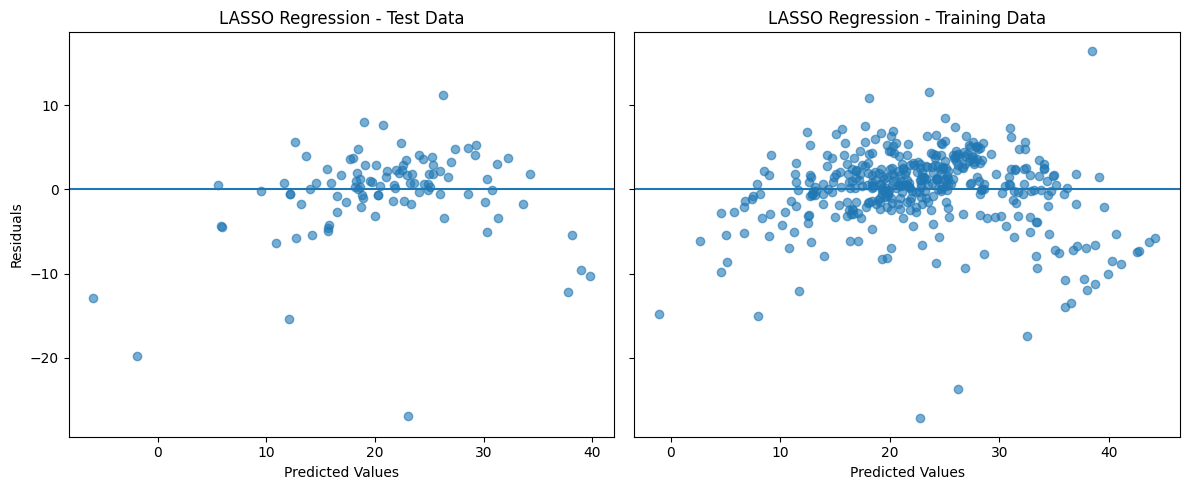

In [ ]:
# 33. Residual plots for lasso

# Create residual plots for the training and test data
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True
)

# Plot residuals for the test data
ax1.scatter(
    y_test_pred_lasso,
    y_test_pred_lasso - y_test,
    alpha=0.6
)

ax1.axhline(y=0)
ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("Residuals")
ax1.set_title("LASSO Regression - Test Data")

# Plot residuals for the training data
ax2.scatter(
    y_train_pred_lasso,
    y_train_pred_lasso - y_train,
    alpha=0.6
)

ax2.axhline(y=0)
ax2.set_xlabel("Predicted Values")
ax2.set_title("LASSO Regression - Training Data")

# Adjust spacing and display
plt.tight_layout()
plt.show()


In [ ]:
# 34. MSE for lasso

# Calculate MSE for the training data
lasso_mse_train = mean_squared_error(
    y_train,
    y_train_pred_lasso
)

# Calculate MSE for the test data
lasso_mse_test = mean_squared_error(
    y_test,
    y_test_pred_lasso
)

print("LASSO MSE - Training:", lasso_mse_train)
print("LASSO MSE - Test:", lasso_mse_test)

LASSO MSE - Training: 21.231401172998687
LASSO MSE - Test: 28.062003616706015


In [ ]:
# 35. R^2 for lasso

# Calculate R^2 for the training data
lasso_r2_train = r2_score(
    y_train,
    y_train_pred_lasso
)

# Calculate R^2 for the test data
lasso_r2_test = r2_score(
    y_test,
    y_test_pred_lasso
)

print("LASSO R² - Training:", lasso_r2_train)
print("LASSO R² - Test:", lasso_r2_test)

LASSO R² - Training: 0.7556052803706992
LASSO R² - Test: 0.6173386615639804


In [ ]:
# 36. Lasso summary

# Create a summary table
lasso_results = pd.DataFrame({
    "Model": ["LASSO Regression"],
    "Alpha": [best_lasso_alpha],
    "Train MSE": [lasso_mse_train],
    "Test MSE": [lasso_mse_test],
    "Train R²": [lasso_r2_train],
    "Test R²": [lasso_r2_test]
})

display(lasso_results)

,Model,Alpha,Train MSE,Test MSE,Train R²,Test R²
0,LASSO Regression,0.1,21.231401,28.062004,0.755605,0.617339


In [ ]:
# 37. Final model comparison table

# Combine results from all three regression models
model_comparison = pd.concat(
    [linear_results, ridge_results, lasso_results],
    ignore_index=True
)

# Display the final comparison table
display(model_comparison)

,Model,Train MSE,Test MSE,Train R²,Test R²,Alpha
0,Linear Regression,20.612847,26.630230,0.762725,0.636863,NaN
1,Ridge Regression,20.703817,26.747207,0.761678,0.635268,10.0
2,LASSO Regression,21.231401,28.062004,0.755605,0.617339,0.1
